In [ ]:
%matplotlib inline
from __future__ import division
import numpy as np
from numpy.random import rand
import matplotlib.pyplot as plt
import numba as nb

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#----------------------------------------------------------------------
##  BLOCK OF FUNCTIONS USED IN THE MAIN CODE
#----------------------------------------------------------------------

def initialstate(N):
    ''' generates a random spin configuration for initial condition'''
    state = 2*np.random.randint(2, size=(N,N))-1
    return state


@nb.njit
def mcmove_original(config, beta):
    '''Monte Carlo move using Metropolis algorithm '''
    for i in range(N):
        for j in range(N):
                a = np.random.randint(0, N)
                b = np.random.randint(0, N)
                s =  config[a, b]
                nb = config[(a+1)%N,b] + config[a,(b+1)%N] + config[(a-1)%N,b] + config[a,(b-1)%N]
                cost = 2*s*nb
                if cost < 0:
                    s *= -1
                elif rand() < np.exp(-cost*beta):
                    s *= -1
                config[a, b] = s
    return config

@nb.njit
def calcEnergy(config):
    '''Energy of a given configuration'''
    energy = 0
    for i in range(len(config)):
        for j in range(len(config)):
            S = config[i,j]
            nb = config[(i+1)%N, j] + config[i,(j+1)%N] + config[(i-1)%N, j] + config[i,(j-1)%N]
            energy += -nb*S
    return energy/2. #Modified here

@nb.njit
def calcMag(config):
    '''Magnetization of a given configuration'''
    mag = np.abs(np.sum(config)) #Modified to absolute value here
    return mag

In [ ]:
@nb.njit
def mcmove(config, beta):
    '''Monte Carlo move using Metropolis algorithm '''

    prob=np.array([0,np.exp(-4*beta),np.exp(-8*beta)])
    for i in range(N):
        for j in range(N):
                a = np.random.randint(0, N)
                b = np.random.randint(0, N)
                s =  config[a, b]
                nb = config[(a+1)%N,b] + config[a,(b+1)%N] + config[(a-1)%N,b] + config[a,(b-1)%N]
                cost = 2*s*nb
                if cost < 0:
                    s *= -1
                elif(rand()<prob[int(cost//4)]):
                    s *=-1

                config[a,b] = s
    return config

In [ ]:
#ALternate Implementation
4//4

1

In [ ]:
## change these parameters for a smaller (faster) simulation
nt      = 60        #  number of temperature points
N       = 16      #  size of the lattice, N x N
eqSteps = 10000   #  number of MC sweeps for equilibration
mcSteps = 100000    #  number of MC sweeps for calculation

T       = np.linspace(1.9, 3, nt);
E,M,C,X = np.zeros(nt), np.zeros(nt), np.zeros(nt), np.zeros(nt)
n1, n2  = 1.0/(mcSteps*N*N), 1.0/(mcSteps*mcSteps*N*N)
# divide by number of samples, and by system size to get intensive values

In [ ]:
#----------------------------------------------------------------------
#  MAIN PART OF THE CODE
#----------------------------------------------------------------------
for tt in range(nt):
    E1 = M1 = E2 = M2 = 0
    config = initialstate(N)
    iT=1.0/T[tt]; iT2=iT*iT;

    for i in range(eqSteps):         # equilibrate
        mcmove(config, iT)           # Monte Carlo moves

    for i in range(mcSteps):
        mcmove(config, iT)
        Ene = calcEnergy(config)     # calculate the energy
        Mag = calcMag(config)        # calculate the magnetisation

        E1 = E1 + Ene
        M1 = M1 + Mag
        M2 = M2 + Mag*Mag
        E2 = E2 + Ene*Ene

    E[tt] = n1*E1
    M[tt] = n1*M1
    C[tt] = (n1*E2 - n2*E1*E1)*iT2
    X[tt] = (n1*M2 - n2*M1*M1)*iT

In [ ]:
data=[E,M,C,X]
data

[array([-1.81073422, -1.79915219, -1.78588344, -1.77419063, -1.76169859,
        -1.74913875, -1.73953469, -1.71843141, -1.70756531, -1.69035719,
        -1.67449406, -1.65770859, -1.64195406, -1.60988109, -1.59421172,
        -1.57029406, -1.55437859, -1.52392   , -1.49893016, -1.46726719,
        -1.45575703, -1.41840109, -1.39124078, -1.35668109, -1.33718203,
        -1.29613703, -1.27767406, -1.24895547, -1.21993734, -1.19749813,
        -1.19203141, -1.15497781, -1.13336234, -1.11013281, -1.090825  ,
        -1.08651031, -1.05955969, -1.04301172, -1.03253859, -1.01907219,
        -1.00592094, -0.98991031, -0.98238375, -0.96503641, -0.9537475 ,
        -0.94525188, -0.93404375, -0.92424672, -0.91195156, -0.90419328,
        -0.89643828, -0.88501391, -0.87420953, -0.86720156, -0.85826234,
        -0.84914359, -0.84192391, -0.83147   , -0.82528   , -0.81929703]),
 array([0.93920133, 0.9337607 , 0.92784664, 0.92355563, 0.91832703,
        0.91222422, 0.90901508, 0.89858227, 0.89396273

In [ ]:
#Saving the Data
np.savez('/content/drive/My Drive/Colab Notebooks/EMCX_16_10k_1L.npz',data)  # Path to save the file in your Google Drive


print("Data saved successfully!")

Data saved successfully!


In [ ]:
#Loading the data
data_saved=np.load('/content/drive/MyDrive/Colab Notebooks/EMCX_25_8k_2k.npz')
E=data_saved['arr_0'][0]
M=data_saved['arr_0'][1]
C=data_saved['arr_0'][2]
X=data_saved['arr_0'][3]

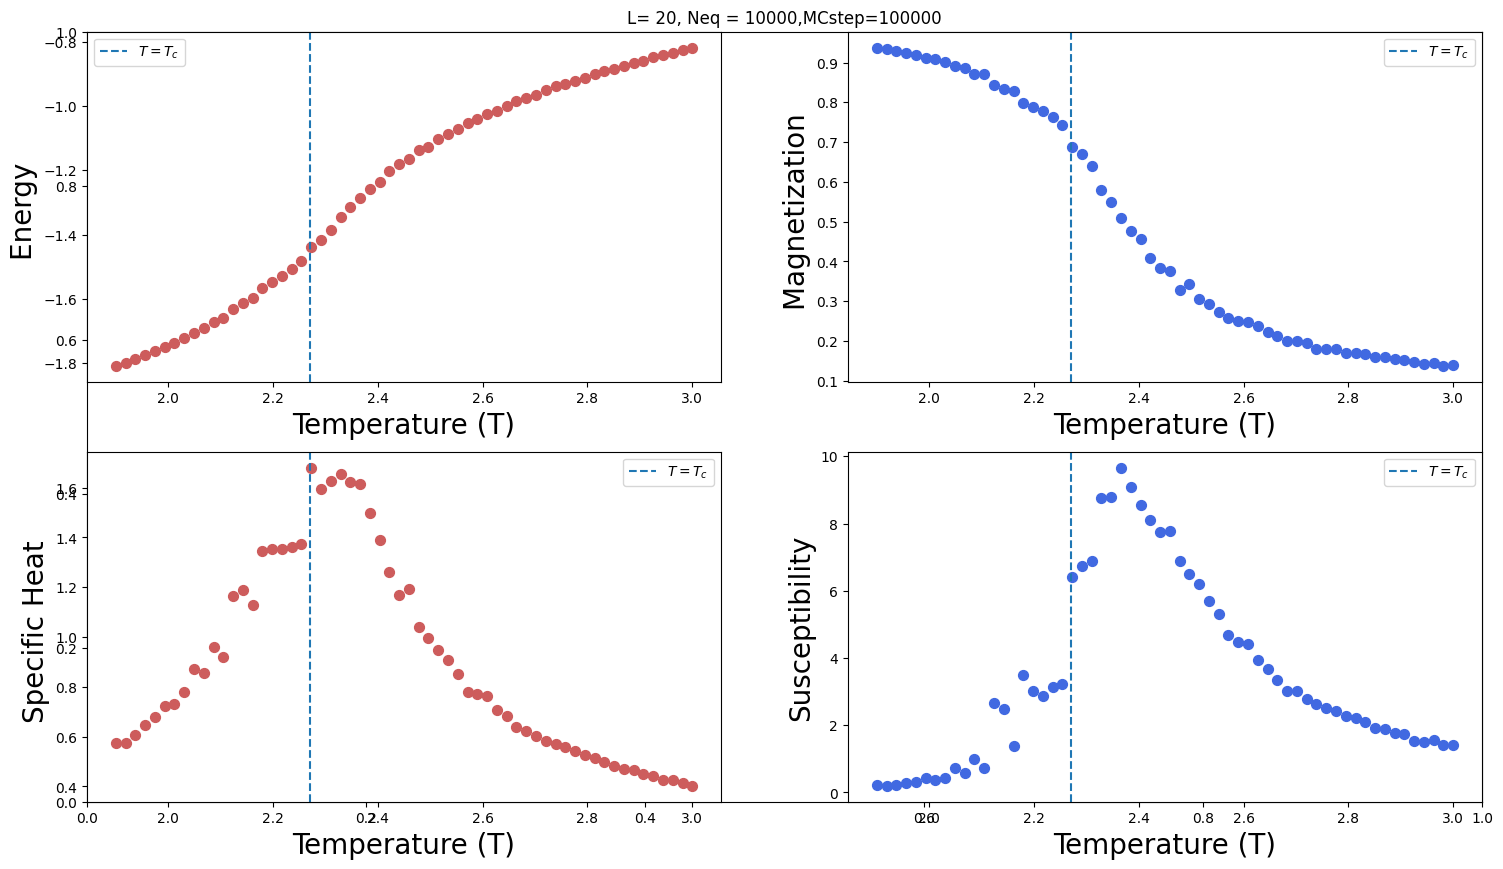

In [ ]:
#include some Individual Cases to put forth the point, like different L effects and other things
f = plt.figure(figsize=(18, 10)); # plot the calculated values
plt.title('L= '+str(N)+', Neq = '+str(eqSteps)+',MCstep='+str(mcSteps))
sp =  f.add_subplot(2, 2, 1 );
plt.scatter(T, E, s=50, marker='o', color='IndianRed')
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Energy ", fontsize=20);         plt.axis('tight');
plt.axvline(x=2.27,linestyle='dashed',label='$T=T_{c}$')
plt.legend()

sp =  f.add_subplot(2, 2, 2 );
plt.scatter(T, abs(M), s=50, marker='o', color='RoyalBlue')
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Magnetization ", fontsize=20);   plt.axis('tight');
plt.axvline(x=2.27,linestyle='dashed',label='$T=T_{c}$')
plt.legend()

sp =  f.add_subplot(2, 2, 3 );
plt.scatter(T, C, s=50, marker='o', color='IndianRed')
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Specific Heat ", fontsize=20);   plt.axis('tight');
plt.axvline(x=2.27,linestyle='dashed',label='$T=T_{c}$')
plt.legend()

sp =  f.add_subplot(2, 2, 4 );
plt.scatter(T, X, s=50, marker='o', color='RoyalBlue')
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Susceptibility", fontsize=20);   plt.axis('tight');
plt.axvline(x=2.27,linestyle='dashed',label='$T=T_{c}$')
plt.legend()

In [ ]:
#Plotting for different L=20,30,40  Cv and X vs T
data20=np.load('/content/drive/MyDrive/Colab Notebooks/EMCX_20_10k_1L.npz')
data30=np.load('/content/drive/MyDrive/Colab Notebooks/EMCX_30_10k_2.5L.npz')
data16=np.load('/content/drive/MyDrive/Colab Notebooks/EMCX_16_10k_1L.npz')

In [ ]:
C20=data20['arr_0'][2]
C30=data30['arr_0'][2]
C16=data16['arr_0'][2]
X20=data20['arr_0'][3]
X30=data30['arr_0'][3]
X16=data16['arr_0'][3]
E20=data20['arr_0'][0]
E30=data30['arr_0'][0]
E16=data16['arr_0'][0]
M20=data20['arr_0'][1]
M30=data30['arr_0'][1]
M16=data16['arr_0'][1]

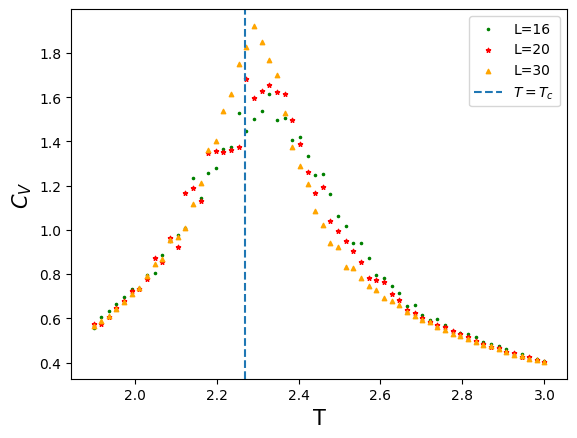

In [ ]:
plt.scatter(T,C16,s=10, marker='.',label='L=16',color='green')
plt.scatter(T,C20,s=10, marker='*',label='L=20',color='red')
plt.scatter(T,C30,s=10, marker='^',label='L=30',color='orange')

plt.ylabel('$C_{V}$',fontsize='15')
plt.xlabel('T',fontsize='15')
plt.axvline(x=2.27,linestyle='dashed',label='$T=T_{c}$')
plt.legend()
plt.show()


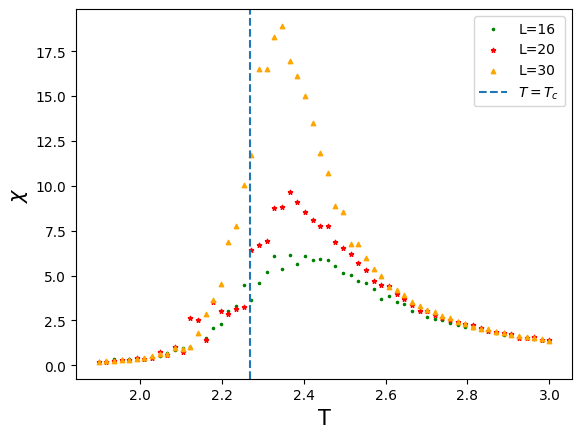

In [ ]:
plt.scatter(T,X16,s=10, marker='.',label='L=16',color='green')
plt.scatter(T,X20,s=10, marker='*',label='L=20',color='red')
plt.scatter(T,X30,s=10, marker='^',label='L=30',color='orange')

plt.ylabel('$\chi$',fontsize='15')
plt.xlabel('T',fontsize='15')
plt.axvline(x=2.27,linestyle='dashed',label='$T=T_{c}$')
plt.legend()
plt.show()


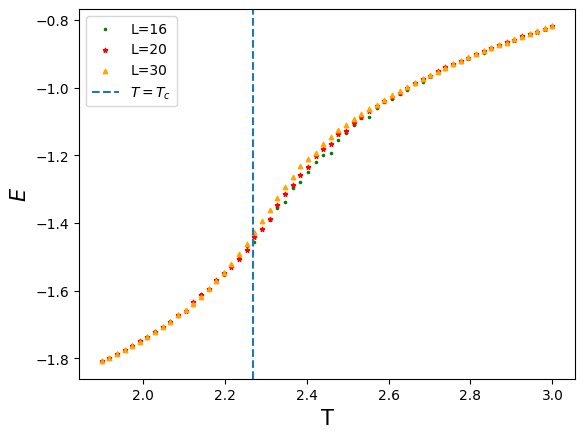

In [ ]:
plt.scatter(T,E16,s=10, marker='.',label='L=16',color='green')
plt.scatter(T,E20,s=10, marker='*',label='L=20',color='red')
plt.scatter(T,E30,s=10, marker='^',label='L=30',color='orange')

plt.ylabel('$E$',fontsize='15')
plt.xlabel('T',fontsize='15')
plt.axvline(x=2.27,linestyle='dashed',label='$T=T_{c}$')
plt.legend()
plt.show()


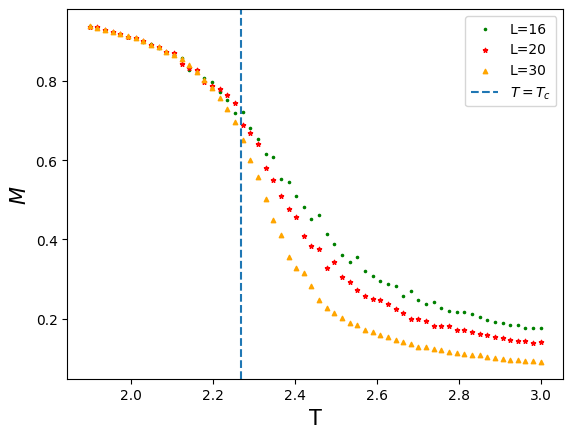

In [ ]:
plt.scatter(T,M16,s=10, marker='.',label='L=16',color='green')
plt.scatter(T,M20,s=10, marker='*',label='L=20',color='red')
plt.scatter(T,M30,s=10, marker='^',label='L=30',color='orange')

plt.ylabel('$M$',fontsize='15')
plt.xlabel('T',fontsize='15')
plt.axvline(x=2.27,linestyle='dashed',label='$T=T_{c}$')
plt.legend()
plt.show()